In [1]:
import uproot
import pandas as pd
import numpy as np
import glob


In [2]:
import matplotlib.pyplot as plt
plt.style.use('default')
plt.style.use('belle2')

import os

In [3]:
import glob

# base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13/proc13_etaetapip_loose_v7_250122_temp"
# cm_elements = ["etahp_13_had_4S_off_v1", "etahp_13_had_4S_v3", "etahp_23_had_4S_off_v1", "etahp_23_had_4S_v1", "etahp_23_had_5Sscan_10657_v1", "etahp_23_had_5Sscan_10706_v1",\
               # "etahp_23_had_5Sscan_10751_v1", "etahp_23_had_5Sscan_10810_v1"]
# base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13_all/proc13_all_etapip_loose_v7_250205_Dp_dz"
# base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13_all/proc13_all_etapip_loose_v7_250205_Dp_dz_skimhad"
base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/proc13_all/proc13_all_etapip_loose_v7_250216_CMS_Psum"
cm_elements = ["etahp_13_4S_off_v1", "etahp_13_4S_v2", "etahp_23_4S_off_v1", "etahp_23_4S_v1", "etahp_23_5Sscan_10657_v1", "etahp_23_5Sscan_10706_v1",\
               "etahp_23_5Sscan_10751_v1", "etahp_23_5Sscan_10810_v1"]

cut_expression = "Dp_M>0"
tree_name = "etapip_pipipi_K"

file_list = []
for element in cm_elements:
    # pattern = f"{base_path}/{element}/*.root"
    pattern = f"{base_path}/{element}/{tree_name}/*.BCS.root"

    file_list += glob.glob(pattern)


dataframes = []
# Process each file
for file_name in file_list:
    # Load the ROOT file and tree
    file = uproot.open(file_name)
    tree = file[tree_name]

    # Specify the branches you want to extract
    # branches = ['Pip_pionID','Dp_Psum','Pip_genMotherID','etapip_Eta_genMotherID','Pip_genMotherPDG','etapip_Eta_genMotherPDG','Dp_cosHelicityAngleMomentum','Pip_dr',"Dp_isSignal","Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane", "Pip_p","Dp_CMS_p","etapip_Eta_p","CFT_prob","Dp_M","num_Dstar_no_nan",]  # Replace with actual branch names

    branches = ['Dp_M','Dp_CMS_cosTheta','Pip_cosTheta','Pip_p','Pip_charge']
    # Convert the selected branches to a Pandas DataFrame
    # df_temp = tree.arrays(branches, library="pd")
    df_temp = tree.arrays(
        branches,
        library="pd",
        entry_start=None,  # Optional: start at a specific entry
        entry_stop=None,   # Optional: stop at a specific entry
        filter_name=branches,  # Load only specified branches
        cut=cut_expression  # Apply the cut
    )
    # df_temp = tree.arrays(library="pd")

    # Append the DataFrame to the list
    dataframes.append(df_temp)

In [4]:
df_proc13 = pd.concat(dataframes, ignore_index=True)


In [5]:
df_proc13.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,3145.000000,3145.000000,3145.000000,3145.000000,3145.000000
mean,1.672323,0.147221,0.383492,1.775134,0.002226
std,0.144185,0.498991,0.476592,0.696771,1.000157
min,1.500001,-0.913715,-0.883416,0.405371,-1.000000
25%,1.576269,-0.316466,-0.005979,1.288358,-1.000000
50%,1.635464,0.220678,0.534541,1.694009,1.000000
75%,1.719299,0.600713,0.805337,2.202700,1.000000
max,2.099739,0.981706,0.965583,4.729052,1.000000


In [6]:
df_proc13 = df_proc13.query('Dp_M> 1.73 & Dp_M<2.1')


In [7]:
df_proc13.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,732.000000,732.000000,732.000000,732.000000,732.000000
mean,1.884533,0.168956,0.409036,1.838768,-0.008197
std,0.140150,0.521068,0.505426,0.747739,1.000650
min,1.730300,-0.884946,-0.841656,0.425823,-1.000000
25%,1.768841,-0.325739,-0.007353,1.304161,-1.000000
50%,1.806534,0.262117,0.609900,1.796173,-1.000000
75%,2.050748,0.631249,0.859429,2.314317,1.000000
max,2.099739,0.981706,0.965468,4.729052,1.000000


In [8]:
nan_columns = df_proc13.isnull().any()
print(nan_columns)

Dp_M               False
Dp_CMS_cosTheta    False
Pip_cosTheta       False
Pip_p              False
Pip_charge         False
dtype: bool


In [22]:
import glob

# base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/etapip_eteeta/MC15rd_etaetapip_loose_v7_241213_temp"
# base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/etapip_eteeta/MC15rd_etaetapip_loose_v7_250122_skimhad_if_false"
# base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/etapip_eteeta/MC15rd_etaetapip_loose_v7_250122_skimhad_if_true"

base_path = "/share/storage/jykim/storage_b2/storage/reduced_ntuples/MC15rd/etapip_eteeta/MC15rd_etaetapip_loose_v7_250122_skimhad_if_true_Dp_CMS_p"
cm_elements = ["15rd_eta_e7_18_4S_v3", "15rd_eta_e20_b26_v1", "15rd_eta_e20_e26_4S_v2", "15rd_eta_e21_5S_scan_v1", "15rd_eta_mori_off_v1"]

cut_expression = "Dp_M>0"
tree_name = "etapip_pipipi_K"

file_list = []
for element in cm_elements:
    # pattern = f"{base_path}/{element}/*.root"
    # pattern = f"{base_path}/{element}/{tree_name}/*.BCS.root"
    # pattern = f"{base_path}/{element}/{tree_name}/train_Dp_dz/all/*.BCS.root"
    pattern = f"{base_path}/{element}/{tree_name}/train_Dp_dz/skimhad/ref/*.BCS.root"

    file_list += glob.glob(pattern)


dataframes = []
# Process each file
for file_name in file_list:
    # Load the ROOT file and tree
    file = uproot.open(file_name)
    tree = file[tree_name]

    # Specify the branches you want to extract
    # branches = ['Pip_pionID','Dp_Psum','Pip_genMotherID','etapip_Eta_genMotherID','Pip_genMotherPDG','etapip_Eta_genMotherPDG','Dp_cosHelicityAngleMomentum','Pip_dr',"Dp_isSignal","Dp_cosAngleBetweenMomentumAndVertexVectorInXYPlane", "Pip_p","Dp_CMS_p","etapip_Eta_p","CFT_prob","Dp_M","num_Dstar_no_nan",]  # Replace with actual branch names

    branches = ['Dp_M','Dp_CMS_cosTheta','Pip_cosTheta','Pip_p','Pip_charge']
    # Convert the selected branches to a Pandas DataFrame
    # df_temp = tree.arrays(branches, library="pd")
    df_temp = tree.arrays(
        branches,
        library="pd",
        entry_start=None,  # Optional: start at a specific entry
        entry_stop=None,   # Optional: stop at a specific entry
        filter_name=branches,  # Load only specified branches
        cut=cut_expression  # Apply the cut
    )
    # df_temp = tree.arrays(library="pd")

    # Append the DataFrame to the list
    dataframes.append(df_temp)

In [23]:
df_mc15rd = pd.concat(dataframes, ignore_index=True)


ValueError: No objects to concatenate

In [24]:
df_mc15rd.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,6452.000000,6452.000000,6452.000000,6452.000000,6452.000000
mean,1.916247,0.135101,0.392957,1.829461,-0.004030
std,0.093163,0.487641,0.463342,0.758036,1.000069
min,1.730012,-0.906557,-0.894947,0.406317,-1.000000
25%,1.851927,-0.291708,0.025681,1.282266,-1.000000
50%,1.958648,0.198183,0.523707,1.735637,-1.000000
75%,1.971695,0.556692,0.809316,2.291039,1.000000
max,2.099943,0.992536,0.969694,4.928639,1.000000


In [16]:
df_mc15rd = df_mc15rd.query('Dp_M> 1.73 & Dp_M<2.1')


In [17]:
df_mc15rd.describe()

,Dp_M,Dp_CMS_cosTheta,Pip_cosTheta,Pip_p,Pip_charge
count,6452.000000,6452.000000,6452.000000,6452.000000,6452.000000
mean,1.916247,0.135101,0.392957,1.829461,-0.004030
std,0.093163,0.487641,0.463342,0.758036,1.000069
min,1.730012,-0.906557,-0.894947,0.406317,-1.000000
25%,1.851927,-0.291708,0.025681,1.282266,-1.000000
50%,1.958648,0.198183,0.523707,1.735637,-1.000000
75%,1.971695,0.556692,0.809316,2.291039,1.000000
max,2.099943,0.992536,0.969694,4.928639,1.000000


In [18]:
nan_columns = df_mc15rd.isnull().any()
print(nan_columns)

Dp_M               False
Dp_CMS_cosTheta    False
Pip_cosTheta       False
Pip_p              False
Pip_charge         False
dtype: bool


In [19]:
from plothist import make_hist, plot_hist
from plothist import plot_two_hist_comparison, add_luminosity


/home/jykim/.local/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3378: UserWarning: The recommended fonts to use plothist were not found. You can install them by typing 'install_latin_modern_fonts' in your terminal. If it still does not work, please check the documentation at https://plothist.readthedocs.io/en/latest/usage/font_installation.html
  exec(code_obj, self.user_global_ns, self.user_ns)


In [20]:
tree_to_compare = tree_name
plt.rcParams['font.family'] = 'DejaVu Sans'


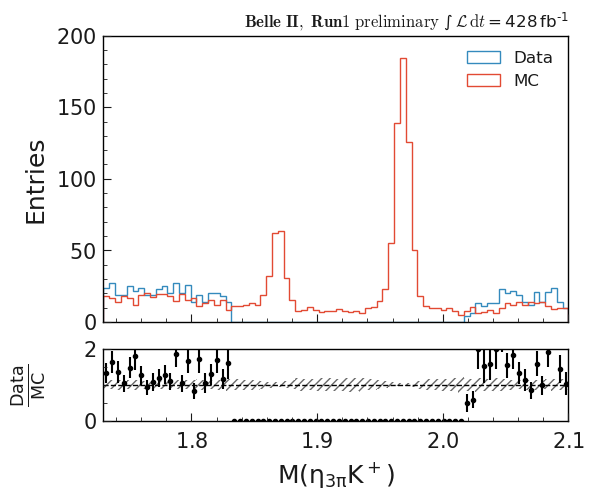

In [21]:
name = "Dp_M"
category = "category"
xlabel = r"$M(\eta_{3\pi} K^+)$"

# x1 = df[name][df[category] == 1]
# x2 = df[name][df[category] == 2]

x1 = df_proc13[name]
x2 = df_mc15rd[name]

# x_range = (min(min(x1), min(x2)), max(max(x1), max(x2)))
# x_range = (min(min(x1), min(x2)),5.1)
x_range = (1.73,2.1)

h1 = make_hist(x1, bins=80, range=x_range, weights=1)
h2 = make_hist(x2, bins=80, range=x_range, weights=1/4)


# Default comparison is ratio
fig, ax_main, ax_comparison = plot_two_hist_comparison(
    h1,
    h2,
    xlabel=xlabel,
    ylabel="Entries",
    h1_label="Data",
    h2_label="MC",
    comparison="split_ratio",
)
add_luminosity(
    collaboration="Belle II, Run1", ax=ax_main, lumi=428, lumi_unit="fb", preliminary=True
)
fig.savefig(f"proc13_MC15rd_{tree_to_compare}_{name}_skimhad_Dp_CMS_p.png", bbox_inches="tight")